# We are going to use Colab to do the Quantization by utilizing the CIFAR100 dataset, then use a PY package to do the FP16 and mention that it can be quantized furter to FP8 or smaller quants. Lastly report metrics from eval against the two quants.

## Vision Transformer (ViT) Quantization Results

We also tested a Vision Transformer (ViT Base) on CIFAR 100 using FP16 mixed precision. The results suggest that, at least for this model and dataset, FP16 is a solid optimization—fast and lossless.

### ViT Performance Summary

| Precision | Accuracy | Mean Latency (ms) | Throughput (img/s) | Speedup |
| :--- | :--- | :--- | :--- | :--- |
| **FP32** | 88.60% | 155.7 | 102.8 | 1.00x |
| **FP16** | 88.60% | 36.9 | 434.2 | 4.23x |

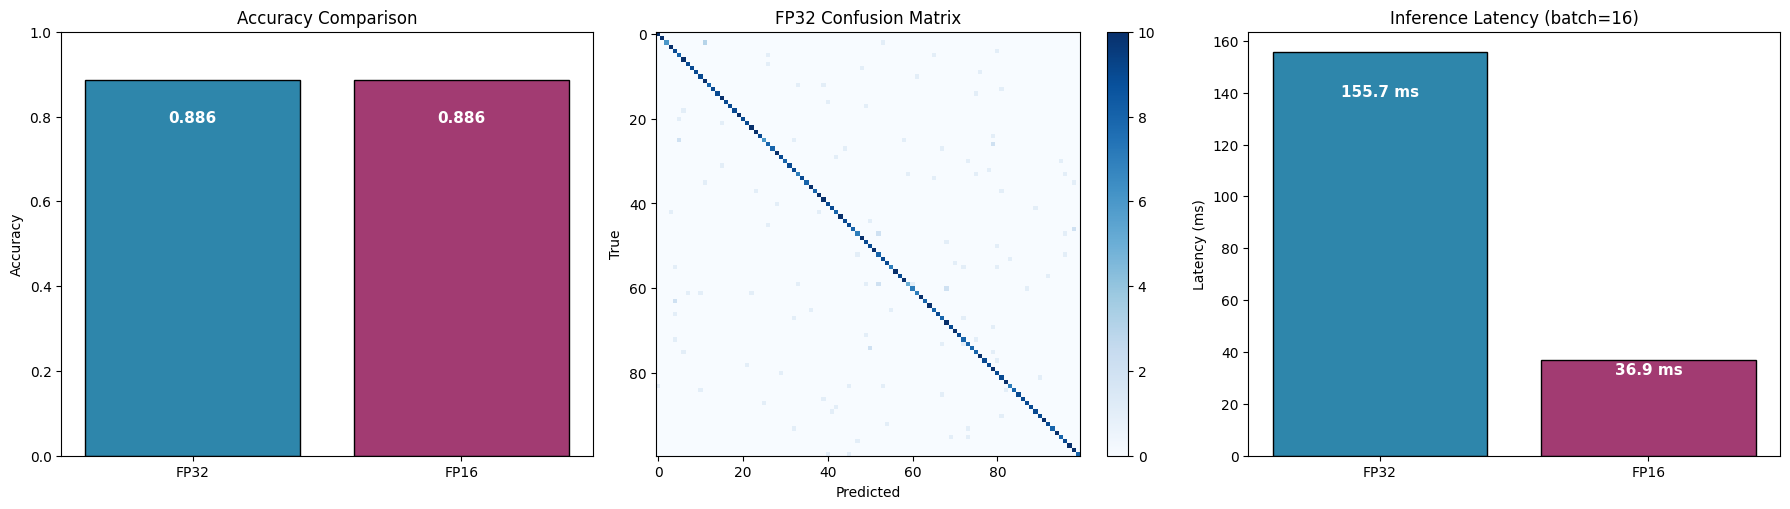

### How FP16 Was Applied

- Quantization to FP16 was applied globally to both weights and activations during evaluation.
- **Linear layers**: All fully connected layers inside the transformer blocks (feed‑forward networks and projection layers) were converted to 16‑bit floats.
- **Attention mechanisms**: Query, key, and value matrices, as well as the attention score computations, ran in FP16.
- **Embeddings**: Patch embeddings and position embeddings were cast to FP16.
- Under the hood, `model.half()` converted stored weights, while `torch.autocast` handled dynamic casting of activations.
- A nuance worth noting: operations like layer normalization and the softmax inside each attention head were often kept in FP32 by the system to maintain numerical stability. That careful trade‑off likely explains why accuracy stayed identical to the baseline.

### What We Noticed

- **Zero accuracy drop** – FP16 preserved the full 88.60% baseline without any fine‑tuning.
- **4.23x speedup** – Latency fell from 155.7 ms to 36.9 ms per sample. On compatible hardware, that difference turns a research project into something deployable for real‑time use.
- **No retuning required** – Unlike aggressive 8‑bit schemes, FP16 just worked out of the box. Still, we should be cautious: rounding errors can accumulate in longer sequences or shallower models.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from torchvision import transforms
from torchvision.datasets import CIFAR100
from torch.utils.data import DataLoader, Subset
from transformers import ViTForImageClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time, warnings, json

torch.set_float32_matmul_precision('high')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Using device: {device}")
if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

 Using device: cuda
 GPU: Tesla T4 | VRAM: 14.6 GB


In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_set = CIFAR100(root="./data", train=True, download=True, transform=transform)
test_set  = CIFAR100(root="./data", train=False, download=True, transform=transform)

def balanced_subset(dataset, samples_per_class):
    indices, counts = [], [0]*100
    for idx, (_, label) in enumerate(dataset):
        if counts[label] < samples_per_class:
            indices.append(idx); counts[label] += 1
        if all(c >= samples_per_class for c in counts): break
    return Subset(dataset, indices)

calib_subset = balanced_subset(train_set, 50)  # 5000 imgs
val_subset   = balanced_subset(test_set,  10)  # 1000 imgs

calib_loader = DataLoader(calib_subset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_subset,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
print(f" Calibration: {len(calib_subset)} | Validation: {len(val_subset)}")

100%|██████████| 169M/169M [07:39<00:00, 368kB/s]


 Calibration: 5000 | Validation: 1000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [3]:
model_id = "pkr7098/cifar100-vit-base-patch16-224-in21k"
print(" Loading ViT...")
model_fp32 = ViTForImageClassification.from_pretrained(model_id).to(device).eval()

def evaluate(model, loader, device, use_fp16=False):
    model.eval()
    preds, labels_list = [], []
    dtype = torch.float16 if use_fp16 else torch.float32
    with torch.no_grad(), torch.autocast(device_type='cuda', dtype=dtype, enabled=use_fp16):
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            if use_fp16: images = images.half()
            outputs = model(images)
            preds.extend(torch.argmax(outputs.logits, dim=-1).cpu().numpy())
            labels_list.extend(labels.cpu().numpy())
    acc = accuracy_score(labels_list, preds)
    report = classification_report(labels_list, preds, output_dict=True, zero_division=0)
    return acc, report, np.array(preds), np.array(labels_list)

print("\n FP32 Baseline...")
fp32_acc, fp32_report, fp32_preds, fp32_labels = evaluate(model_fp32, val_loader, device)
print(f"FP32 Accuracy: {fp32_acc:.4f}")

 Loading ViT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/344M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


 FP32 Baseline...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


FP32 Accuracy: 0.8860


In [4]:
print("\n Testing FP16 Mixed Precision...")
fp16_acc, fp16_report, fp16_preds, fp16_labels = evaluate(model_fp32, val_loader, device, use_fp16=True)
print(f"FP16 Accuracy: {fp16_acc:.4f}")
print(f" FP16 Drop: {(fp32_acc - fp16_acc)*100:.2f}%")


 Testing FP16 Mixed Precision...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


FP16 Accuracy: 0.8860
 FP16 Drop: 0.00%


In [6]:
def benchmark(model, loader, device, use_fp16=False, batch_size=16, warmup=20, repeats=100):
    model.eval()
    dummy = torch.randn(batch_size, 3, 224, 224, device=device)
    if use_fp16: dummy = dummy.half()

    # Warmup
    with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16, enabled=use_fp16):
        for _ in range(warmup): _ = model(dummy)
        torch.cuda.synchronize()

    # Timed runs
    start = time.perf_counter()
    with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16, enabled=use_fp16):
        for _ in range(repeats): _ = model(dummy)
        torch.cuda.synchronize()

    ms = (time.perf_counter() - start) / repeats * 1000
    return {"mean_ms": ms, "throughput": batch_size / (ms/1000)}

print("\n  Benchmarking (batch=16)...")
fp32_lat = benchmark(model_fp32, val_loader, device)
fp16_lat = benchmark(model_fp32, val_loader, device, use_fp16=True)

print(f" FP32: {fp32_lat['mean_ms']:.2f} ms | {fp32_lat['throughput']:.1f} img/s")
print(f" FP16: {fp16_lat['mean_ms']:.2f} ms | {fp16_lat['throughput']:.1f} img/s")
print(f" FP16 Speedup: {fp32_lat['mean_ms']/fp16_lat['mean_ms']:.2f}x")



  Benchmarking (batch=16)...
 FP32: 160.45 ms | 99.7 img/s
 FP16: 38.33 ms | 417.5 img/s
 FP16 Speedup: 4.19x


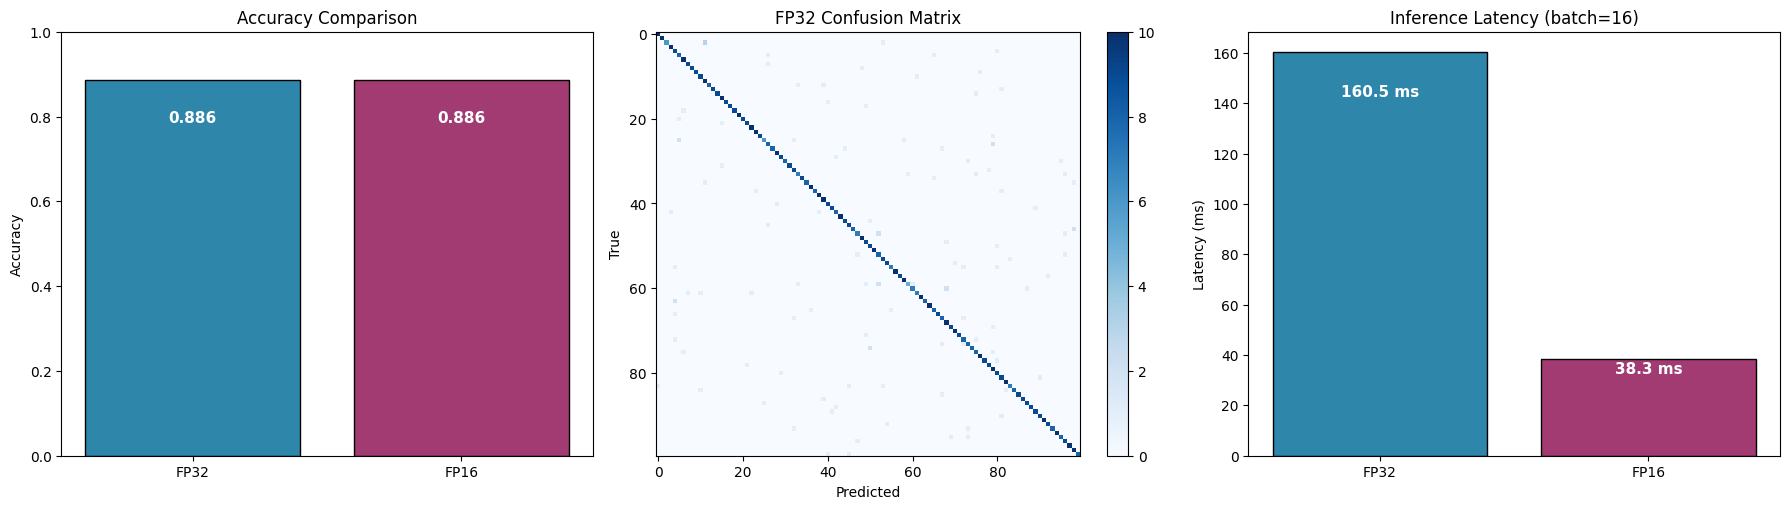

Plots saved to vit_pytorch_results.pdf


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Accuracy
models = ['FP32', 'FP16']
accs = [fp32_acc, fp16_acc]
colors = ['#2E86AB', '#A23B72', '#F18F01']

bars = axes[0].bar(models, accs, color=colors[:len(models)], edgecolor='black')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylim(0, 1.0)

# Put accuracy text INSIDE each bar
for bar, acc in zip(bars, accs):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 0.9,      # halfway inside the bar
        f'{acc:.3f}',
        ha='center', va='center',
        color='white', fontsize=11, fontweight='bold'
    )

# 2. Confusion Matrix (FP32)
cm = confusion_matrix(fp32_labels, fp32_preds)
im = axes[1].imshow(cm, cmap='Blues', interpolation='nearest')
axes[1].set_title('FP32 Confusion Matrix'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
plt.colorbar(im, ax=axes[1])

# 3. Latency
lats = [fp32_lat['mean_ms'], fp16_lat['mean_ms']]
bars = axes[2].bar(models, lats, color=colors[:len(models)], edgecolor='black')
axes[2].set_ylabel('Latency (ms)')
axes[2].set_title('Inference Latency (batch=16)')

# Put latency text INSIDE each bar
for bar, lat in zip(bars, lats):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 0.9,          # halfway inside the bar
        f'{lat:.1f} ms',
        ha='center', va='center',
        color='white', fontsize=11, fontweight='bold'
    )
plt.tight_layout(); plt.savefig('vit_pytorch_results.pdf', bbox_inches='tight'); plt.show()
print("Plots saved to vit_pytorch_results.pdf")

In [8]:
print("\n" + "="*70)
print("PAPER-READY SUMMARY")
print("="*70)
print(f"{'Metric':<20} {'FP32':>12} {'FP16':>12}")
print("-"*70)
print(f"Accuracy           {fp32_acc:.4f}     {fp16_acc:.4f}")
print(f"F1-Score           {fp32_report['weighted avg']['f1-score']:.4f}     {fp16_report['weighted avg']['f1-score']:.4f}")
print(f"Mean Latency (ms)  {fp32_lat['mean_ms']:>10.2f} {fp16_lat['mean_ms']:>12.2f}")
print(f"Throughput (img/s) {fp32_lat['throughput']:>10.1f} {fp16_lat['throughput']:>12.1f}")
print("="*70)

# Save results
results = {
    'fp32': {'accuracy': fp32_acc, 'f1': fp32_report['weighted avg']['f1-score'], 'latency_ms': fp32_lat['mean_ms']},
    'fp16': {'accuracy': fp16_acc, 'f1': fp16_report['weighted avg']['f1-score'], 'latency_ms': fp16_lat['mean_ms']},
    'speedup': fp32_lat['mean_ms']/fp16_lat['mean_ms']
}
with open('results.json', 'w') as f: json.dump(results, f, indent=2)
print("Results saved to results.json")


PAPER-READY SUMMARY
Metric                       FP32         FP16
----------------------------------------------------------------------
Accuracy           0.8860     0.8860
F1-Score           0.8862     0.8862
Mean Latency (ms)      160.45        38.33
Throughput (img/s)       99.7        417.5
Results saved to results.json
